<h1>FAKE NEWS CLASSIFIER</h1>

<h2> Setup and Libraries</h2>

In [1]:
!py -3 -m pip install pandas numpy nltk spacy scikit-learn matplotlib seaborn tqdm
!py -3 -m pip install textblob textstat
import pandas as pd
import numpy as np
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') 
nltk.download('stopwords')
nltk.download('wordnet')

!py -3 -m spacy download en_core_web_sm

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data.

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 3.8 MB/s eta 0:00:04
     ----- ---------------------------------- 1.8/12.8 MB 5.7 MB/s eta 0:00:02
     --------- ------------------------------ 2.9/12.8 MB 5.6 MB/s eta 0:00:02
     ------------- -------------------------- 4.5/12.8 MB 6.0 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 6.0 MB/s eta 0:00:02
     ---------------------- ----------------- 7.3/12.8 MB 6.3 MB/s eta 0:00:01
     --------------------------- ------------ 8.7/12.8 MB 6.3 MB/s eta 0:00:01
     ------------------------------- -------- 10.0/12.8 MB 6.3 MB/s eta 0:00:01
     ------------------------------------ --- 11.5/12.8 MB 6.4 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 6.3 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 6.1 MB/s  0:00:02
[+] Download and installation successful
You can now load 

<h2>Dataset Loading</h2>

In [3]:
true_path = r"C:\Users\DELL\Desktop\Fake News Classifier\dataset\True.csv"
fake_path = r"C:\Users\DELL\Desktop\Fake News Classifier\dataset\Fake.csv"

df_true = pd.read_csv(true_path)
df_fake = pd.read_csv(fake_path)

df_true['label'] = 1   # Reliable
df_fake['label'] = 0   # Unreliable

df = pd.concat([df_true, df_fake], ignore_index=True)

df = df[['text', 'label']].dropna()
df.reset_index(drop=True, inplace=True)

print(df.shape)
df.head()

(44898, 2)


,text,label
0,WASHINGTON (Reuters) - The head of a conservat...,1
1,WASHINGTON (Reuters) - Transgender people will...,1
2,WASHINGTON (Reuters) - The special counsel inv...,1
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [4]:
df_true_sample = df[df['label'] == 1].sample(1000, random_state=42)
df_fake_sample = df[df['label'] == 0].sample(1000, random_state=42)

df = pd.concat([df_true_sample, df_fake_sample], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df['label'].value_counts())

label
0    1000
1    1000
Name: count, dtype: int64


<h2>Morphological Preprocessing</h2>

In [5]:
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    sentences = sent_tokenize(text)
    words = word_tokenize(text)
    
    lemmatized = []
    for word in words:
        lemmatized.append(lemmatizer.lemmatize(word.lower()))
    
    return sentences, lemmatized

df['sentences'], df['tokens'] = zip(*df['text'].apply(preprocess))

<h2>POS Feature Engineering</h2>

In [6]:
def extract_pos_features(tokens):
    tags = nltk.pos_tag(tokens)
    
    total = len(tags) if len(tags) > 0 else 1
    
    jjs = sum(1 for word, tag in tags if tag == 'JJS')
    rbs = sum(1 for word, tag in tags if tag == 'RBS')
    nnp = sum(1 for word, tag in tags if tag == 'NNP')
    
    # NEW: adjective count (IMPORTANT for report)
    jj = sum(1 for word, tag in tags if tag in ['JJ', 'JJR', 'JJS'])
    
    pronoun_I_we = sum(1 for word, tag in tags if word.lower() in ['i','we'])
    pronoun_he_she = sum(1 for word, tag in tags if word.lower() in ['he','she'])
    
    return pd.Series({
        'superlative_ratio': (jjs + rbs) / total,
        'proper_noun_ratio': nnp / total,
        'pronoun_ratio': pronoun_I_we / (pronoun_he_she + 1),
        'adjective_count': jj / total   # <-- NEW
    })

tqdm.pandas()
pos_features = df['tokens'].progress_apply(extract_pos_features)

df = pd.concat([df, pos_features], axis=1)

100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:46<00:00, 43.45it/s]


<h2>Syntax Analysis</h2>

In [7]:
def sentence_length(sentences):
    lengths = [len(word_tokenize(s)) for s in sentences if len(s) > 0]
    return np.mean(lengths) if lengths else 0

df['avg_sentence_length'] = df['sentences'].apply(sentence_length)

In [8]:
nlp = spacy.load("en_core_web_sm")

def tree_depth(sentence):
    doc = nlp(sentence)
    
    def depth(token):
        if len(list(token.children)) == 0:
            return 1
        return 1 + max(depth(child) for child in token.children)
    
    depths = [depth(token) for token in doc]
    return max(depths) if depths else 0

In [9]:
real_sentences = df[df['label']==1]['sentences'].explode().dropna().sample(50, random_state=42)
fake_sentences = df[df['label']==0]['sentences'].explode().dropna().sample(50, random_state=42)

real_depth = [tree_depth(s) for s in real_sentences]
fake_depth = [tree_depth(s) for s in fake_sentences]

print("Avg Depth Real:", np.mean(real_depth))
print("Avg Depth Fake:", np.mean(fake_depth))

Avg Depth Real: 7.42
Avg Depth Fake: 7.0


<h2>Stopword Extraction</h2>

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

# Load stopwords
stop_words = set(stopwords.words('english'))

# Keep pronouns 
pronouns = {'i','we','he','she','they','you','me','him','her','us','them'}

# Remove pronouns from stopwords
custom_stopwords = list(stop_words - pronouns)

# TF-IDF with controlled stopword strategy
tfidf = TfidfVectorizer(
    max_features=7000,
    stop_words=custom_stopwords,
    ngram_range=(1,2)   # <-- BIGRAM ADDED
)

X_tfidf = tfidf.fit_transform(df['text'])

<h2>Sentiment and Readability</h2>

In [11]:
#Additional Linguistic Features

from textblob import TextBlob
import textstat

# Sentiment (emotional tone)
def sentiment_score(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['text'].apply(sentiment_score)

# Readability (complexity of text)
df['readability'] = df['text'].apply(textstat.flesch_reading_ease)

<h2>Feature Combination</h2>

In [12]:
linguistic_features = df[
    ['superlative_ratio', 'proper_noun_ratio', 'pronoun_ratio', 
     'avg_sentence_length', 'adjective_count', 'sentiment', 'readability']
].values

from scipy.sparse import hstack

X_combined = hstack([X_tfidf, linguistic_features]).tocsr()
y = df['label']

<h2>t-SNE Visualization</h2>

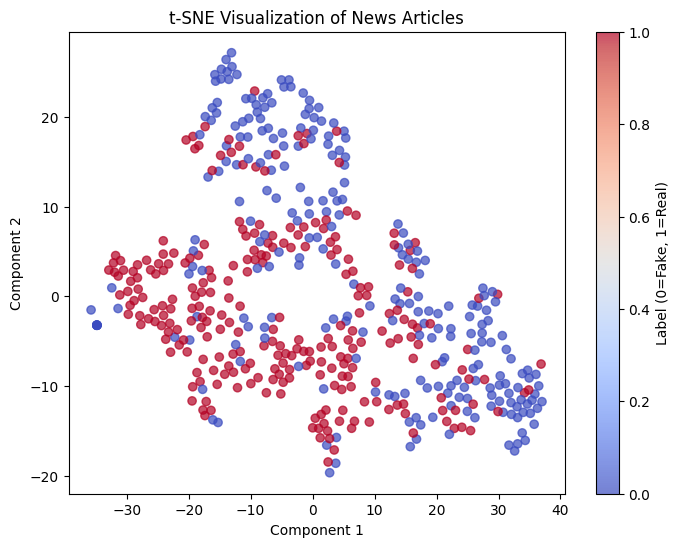

In [13]:
from sklearn.manifold import TSNE

# Reduce dimensionality
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_sample = X_combined[:500].toarray()   # take subset (important for speed)

X_tsne = tsne.fit_transform(X_sample)
y_sample = y.iloc[:500]

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_sample, cmap='coolwarm', alpha=0.7)
plt.title("t-SNE Visualization of News Articles")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Label (0=Fake, 1=Real)")
plt.show()

<H2>Train Test Split</H2>

In [14]:
X_train_idx, X_test_idx = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42
)

X_train_tfidf = X_tfidf[X_train_idx]
X_test_tfidf = X_tfidf[X_test_idx]

X_train_comb = X_combined[X_train_idx]
X_test_comb = X_combined[X_test_idx]

y_train = y.iloc[X_train_idx]
y_test = y.iloc[X_test_idx]

<h2>Model Training</h2>

<h4>Model 1: TF-IDF</h4>

In [15]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train_tfidf, y_train)

y_pred1 = model1.predict(X_test_tfidf)

print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred1))

TF-IDF Accuracy: 0.9725


<h4>Model 2: Combined</h4>

In [16]:
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train_comb, y_train)

y_pred2 = model2.predict(X_test_comb)

print("Combined Accuracy:", accuracy_score(y_test, y_pred2))

Combined Accuracy: 0.965


<h2>Evaluation</h2>

<h4>Classification Report</h4>

In [17]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred2))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.94      0.96       203
           1       0.94      0.99      0.97       197

    accuracy                           0.96       400
   macro avg       0.97      0.97      0.96       400
weighted avg       0.97      0.96      0.96       400



<h4>Confusion Matrix</h4>

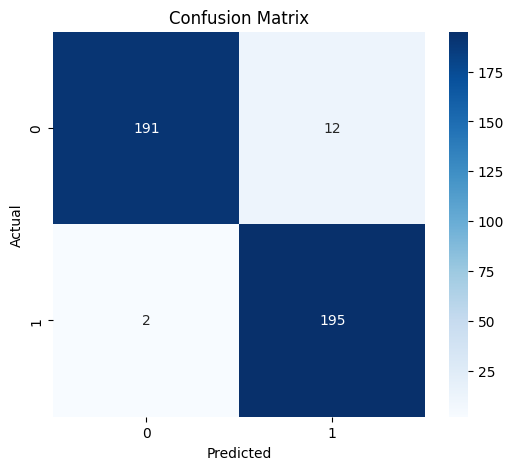

In [18]:
cm = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

<h2>ROC Curve</h2>

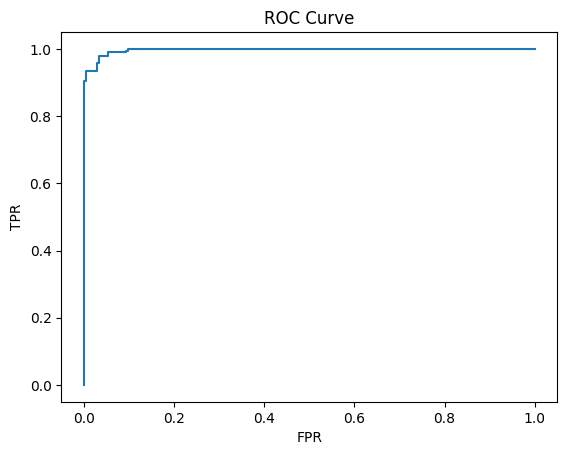

In [19]:
from sklearn.metrics import roc_curve, auc

probs = model2.predict_proba(X_test_comb)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

<h2>Linguistic Profile Report</h2>

In [20]:
profile = df.groupby('label').agg({
    'adjective_count': 'mean',
    'avg_sentence_length': 'mean'
})

print("\nLinguistic Profile (Fake vs Real):")
print(profile)


Linguistic Profile (Fake vs Real):
       adjective_count  avg_sentence_length
label                                      
0             0.095899            33.627084
1             0.107153            31.248343


<h2>POS Feature Distribution</h2>

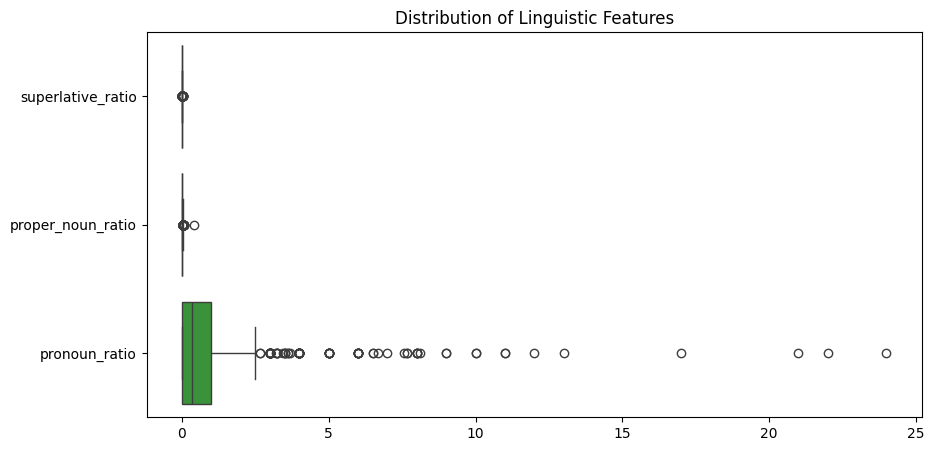

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['superlative_ratio','proper_noun_ratio','pronoun_ratio']], orient='h')
plt.title("Distribution of Linguistic Features")
plt.show()

<h2>Sentence Length Comparison</h2>

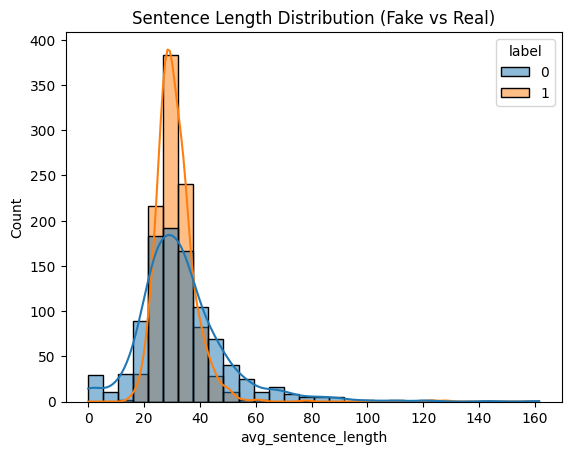

In [22]:
sns.histplot(data=df, x='avg_sentence_length', hue='label', bins=30, kde=True)
plt.title("Sentence Length Distribution (Fake vs Real)")
plt.show()

<h2>Feature Importance (Logistic Regression)</h2>

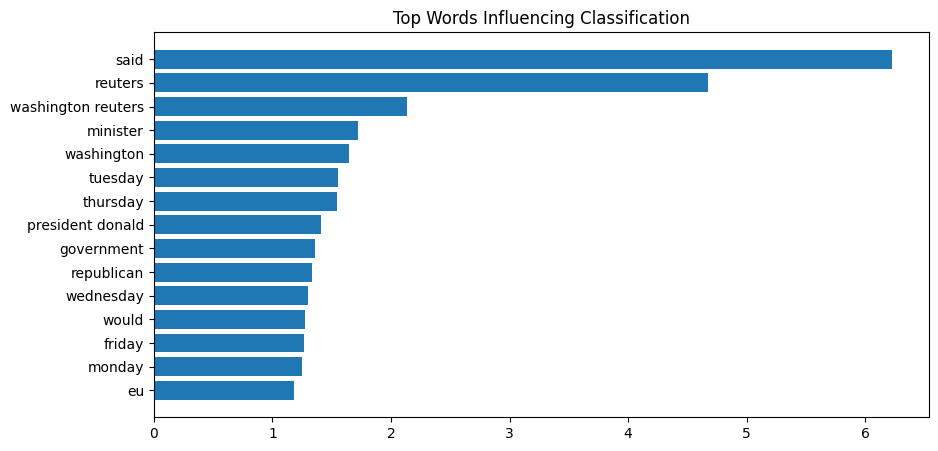

In [23]:
feature_names = tfidf.get_feature_names_out()

coeffs = model1.coef_[0]
top_indices = np.argsort(coeffs)[-15:]

top_words = [feature_names[i] for i in top_indices]
top_scores = coeffs[top_indices]

plt.figure(figsize=(10,5))
plt.barh(top_words, top_scores)
plt.title("Top Words Influencing Classification")
plt.show()

<h2>Sentiment Distribution</h2>

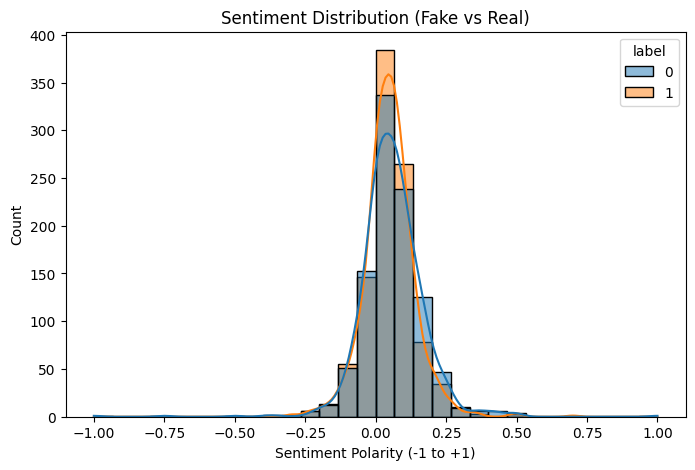

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='sentiment', hue='label', bins=30, kde=True)
plt.title("Sentiment Distribution (Fake vs Real)")
plt.xlabel("Sentiment Polarity (-1 to +1)")
plt.show()

<h2>Readability Comparison</h2>

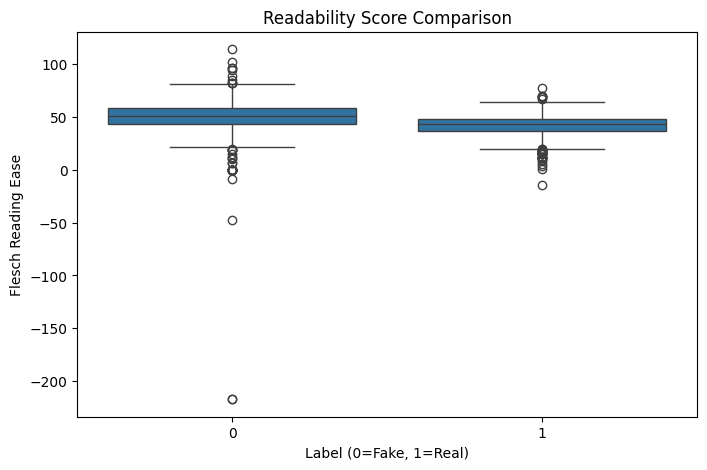

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='readability', data=df)
plt.title("Readability Score Comparison")
plt.xlabel("Label (0=Fake, 1=Real)")
plt.ylabel("Flesch Reading Ease")
plt.show()

<h2>Feature Correlation Heatmap</h2>

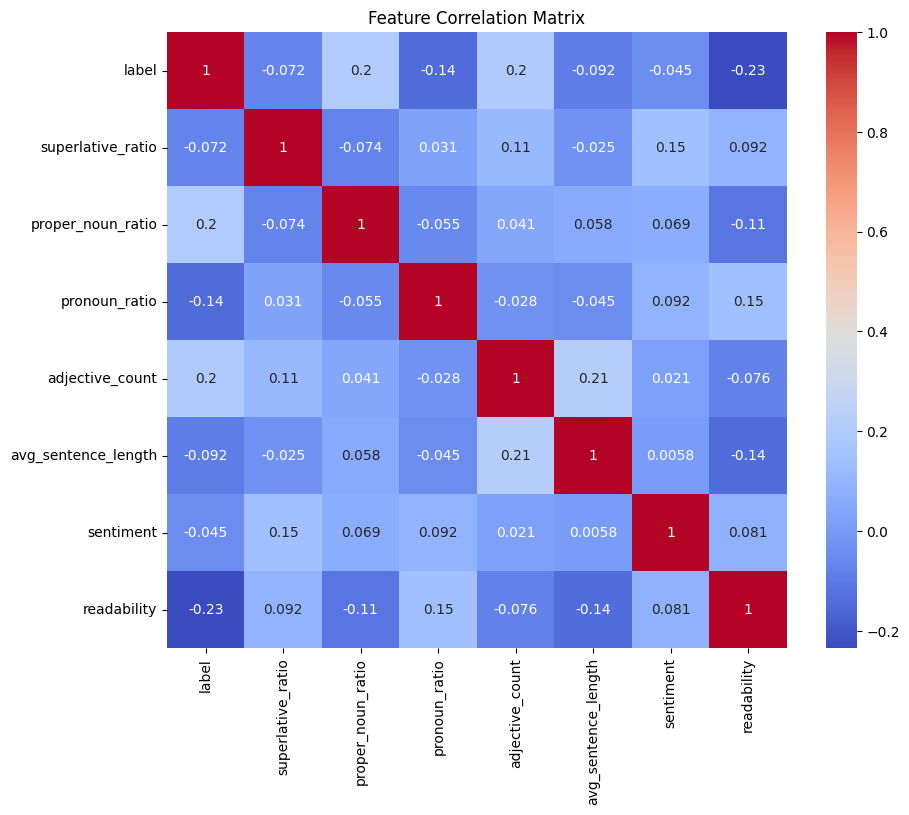

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

<h2>SHAP Graph</h2>

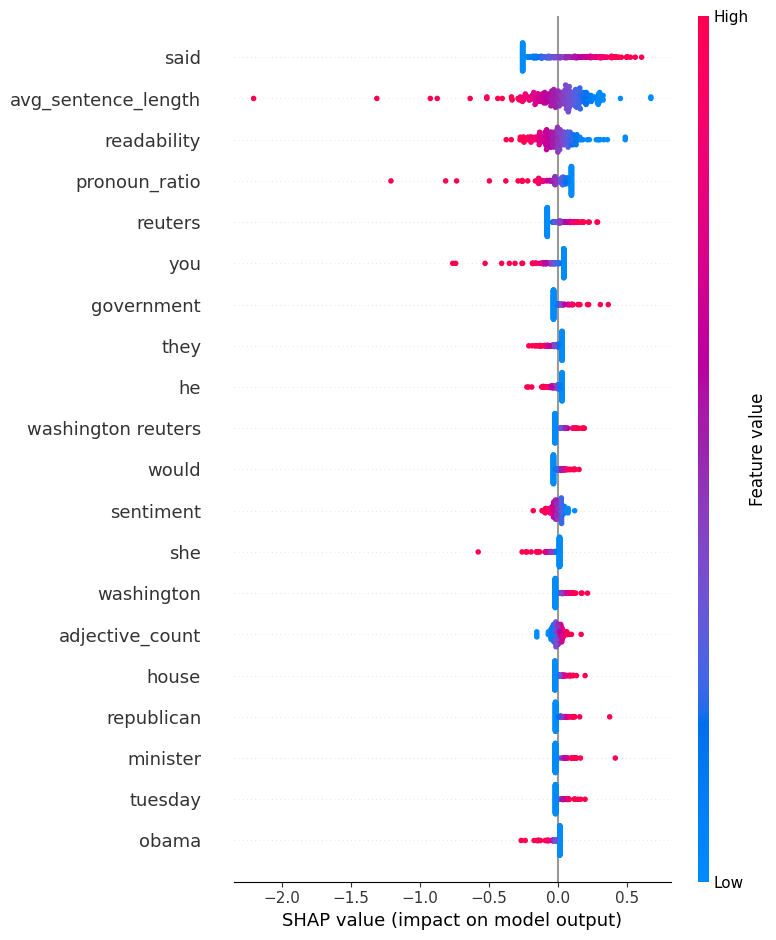

In [27]:
!py -3 -m pip install shap
import shap
import numpy as np

# 🔥 Use a smaller sample (important for speed)
X_sample = X_train_comb[:200]

# 🔥 Convert sparse to dense (required for SHAP)
X_sample_dense = X_sample.toarray()

# 🔥 Create explainer (for logistic regression)
explainer = shap.LinearExplainer(model2, X_sample_dense)

# 🔥 Compute SHAP values
shap_values = explainer.shap_values(X_sample_dense)

# 🔥 Feature names (TF-IDF + linguistic features)
feature_names = tfidf.get_feature_names_out().tolist() + [
    'superlative_ratio', 'proper_noun_ratio', 'pronoun_ratio',
    'avg_sentence_length', 'adjective_count', 'sentiment', 'readability'
]

# 🔥 Summary plot
shap.summary_plot(shap_values, X_sample_dense, feature_names=feature_names)

<h2>Dynamic Error Analysis + SHAP Analysis</h2>


--- RANDOM ERROR ANALYSIS ---
Actual: Fake

Text:
  

--- FEATURE ANALYSIS ---
Superlative Ratio: 0.0
Proper Noun Ratio: 0.0
Pronoun Ratio: 0.0
Adjective Count: 0.0
Avg Sentence Length: 0

--- COMPARISON WITH DATASET ---
Dataset Mean (Fake):
 label                   0.000000
superlative_ratio       0.002316
proper_noun_ratio       0.003357
pronoun_ratio           0.948508
adjective_count         0.095899
avg_sentence_length    33.627084
sentiment               0.059325
readability            49.417329
dtype: float64

Dataset Mean (Real):
 label                   1.000000
superlative_ratio       0.001844
proper_noun_ratio       0.008585
pronoun_ratio           0.511863
adjective_count         0.107153
avg_sentence_length    31.248343
sentiment               0.050043
readability            42.111868
dtype: float64


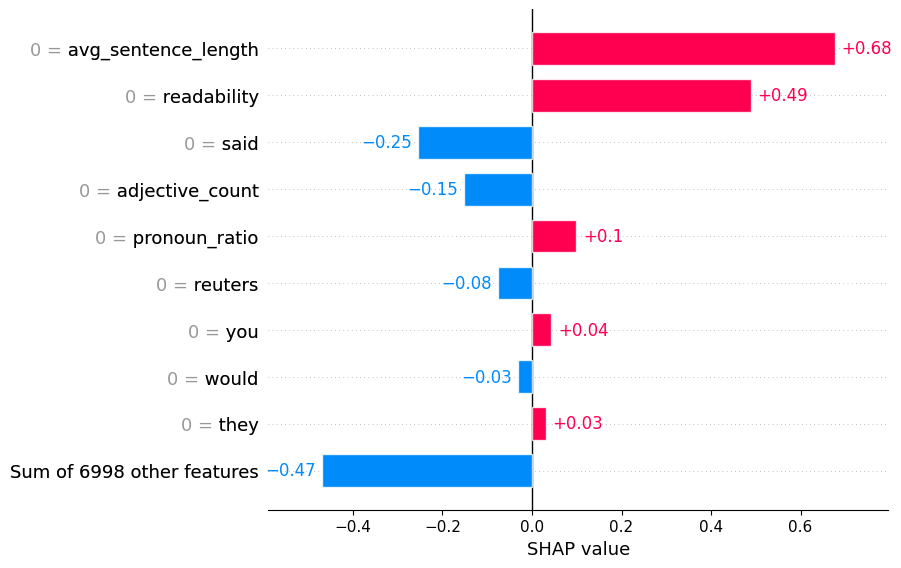

In [28]:
import random
import shap
import numpy as np

df_test = df.iloc[y_test.index]
errors = df_test[y_test != y_pred2]

error_sample = errors.sample(1).iloc[0]
sample_idx = error_sample.name

print("\n--- RANDOM ERROR ANALYSIS ---")
print("Actual:", "Real" if error_sample['label']==1 else "Fake")

text = error_sample['text']
print("\nText:\n", text[:1000])

sentences, tokens = preprocess(text)
pos_feats = extract_pos_features(tokens)
sent_len = sentence_length(sentences)

print("\n--- FEATURE ANALYSIS ---")
print("Superlative Ratio:", pos_feats['superlative_ratio'])
print("Proper Noun Ratio:", pos_feats['proper_noun_ratio'])
print("Pronoun Ratio:", pos_feats['pronoun_ratio'])
print("Adjective Count:", pos_feats['adjective_count'])
print("Avg Sentence Length:", sent_len)

print("\n--- COMPARISON WITH DATASET ---")
print("Dataset Mean (Fake):\n", df[df['label']==0].mean(numeric_only=True))
print("\nDataset Mean (Real):\n", df[df['label']==1].mean(numeric_only=True))

test_indices = y_test.index.tolist()
idx_in_test = test_indices.index(sample_idx)

sample_vector = X_test_comb[idx_in_test]
sample_dense = sample_vector.toarray()

background = X_train_comb[:200].toarray()

explainer = shap.LinearExplainer(model2, background)

shap_values = explainer.shap_values(sample_dense)

feature_names = tfidf.get_feature_names_out().tolist() + [
    'superlative_ratio', 'proper_noun_ratio', 'pronoun_ratio',
    'avg_sentence_length', 'adjective_count', 'sentiment', 'readability'
]

shap.plots.bar(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample_dense[0],
        feature_names=feature_names
    )
)

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    sample_dense[0],
    feature_names=feature_names
)

<h2>SHAP Graph Reasoning for Why a Classification Was Done</h2>

In [29]:
# Pick one sample
idx = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_sample_dense[idx],
    feature_names=feature_names
)